# Multinomial and Categorical Models

When outcomes have **more than two unordered categories**, we need the multinomial distribution.

| Situation | Distribution | Link |
|-----------|-------------|------|
| 2 outcomes, aggregated counts | Binomial | logit |
| 2 outcomes, one row per trial | Bernoulli | logit |
| K outcomes, aggregated counts | Multinomial | softmax |
| K outcomes, one row per trial | Categorical | softmax |

Binomial is just a special case of multinomial with K=2.

**Example**: career choice — individuals choose one of 3 careers. Does family income predict which career they choose?

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from scipy import special

plt.style.use('default')
%matplotlib inline
rng = np.random.default_rng(42)

print(f'PyMC {pm.__version__} | ArviZ {az.__version__}')

PyMC 5.26.1 | ArviZ 0.22.0


## The Softmax Function

For binary outcomes we used the **logit link**: one score → one probability.

For K outcomes we use **softmax**: K scores → K probabilities that sum to 1.

$$p_k = \frac{e^{s_k}}{\sum_{j=1}^{K} e^{s_j}}$$

where $s_k$ is the **score** (linear predictor) for category $k$.

**Identifiability**: with K free scores you could add any constant to all of them without changing the probabilities. So we fix one category's score to 0 — the **reference/pivot category**. Then all other scores are interpreted as *relative* to the reference.

This is exactly the logit for K=2:
- $s_1 = \alpha + \beta x$, $s_2 = 0$ 
- $p_1 = e^{s_1}/(e^{s_1} + 1) = \text{invlogit}(s_1)$ ✓

In [2]:
# Illustrate softmax
def softmax(scores):
    e = np.exp(scores - scores.max())   # subtract max for numerical stability
    return e / e.sum()

# Example: 3 careers with different scores
examples = [
    ([0, 0, 0],    'Equal scores → equal probs'),
    ([2, 0, 0],    'Career 1 strongly favoured'),
    ([0, -1, 0],   'Career 2 disfavoured'),
    ([1, 0.5, 0],  'Typical: career 1 > 2 > 3 (reference)'),
]

print(f'{"Scores":30s}  {"p(career 1)":>12} {"p(career 2)":>12} {"p(career 3)":>12}  Description')
print('-' * 90)
for scores, desc in examples:
    p = softmax(np.array(scores, dtype=float))
    print(f'{str(scores):30s}  {p[0]:12.3f} {p[1]:12.3f} {p[2]:12.3f}  {desc}')

Scores                           p(career 1)  p(career 2)  p(career 3)  Description
------------------------------------------------------------------------------------------
[0, 0, 0]                              0.333        0.333        0.333  Equal scores → equal probs
[2, 0, 0]                              0.787        0.107        0.107  Career 1 strongly favoured
[0, -1, 0]                             0.422        0.155        0.422  Career 2 disfavoured
[1, 0.5, 0]                            0.506        0.307        0.186  Typical: career 1 > 2 > 3 (reference)


## Simulate Career Choice Data

500 individuals each choose one of 3 careers. Family income (standardised) affects the choice:
- Higher income → more likely to choose career 1 (e.g. finance)
- Income has no effect on career 2 (e.g. education)
- Career 3 is the **reference** (score fixed to 0)

Model:
$$s_{i,k} = \alpha_k + \beta_k \cdot \text{income}_i \quad (k = 1, 2)$$
$$s_{i,3} = 0 \quad \text{(reference)}$$
$$p_{i,k} = \text{softmax}(s_{i,1}, s_{i,2}, s_{i,3})_k$$
$$\text{career}_i \sim \text{Categorical}(p_{i,1}, p_{i,2}, p_{i,3})$$

Career distribution: [270  63 167] (careers 0, 1, 2)
Proportions: [0.54  0.126 0.334]


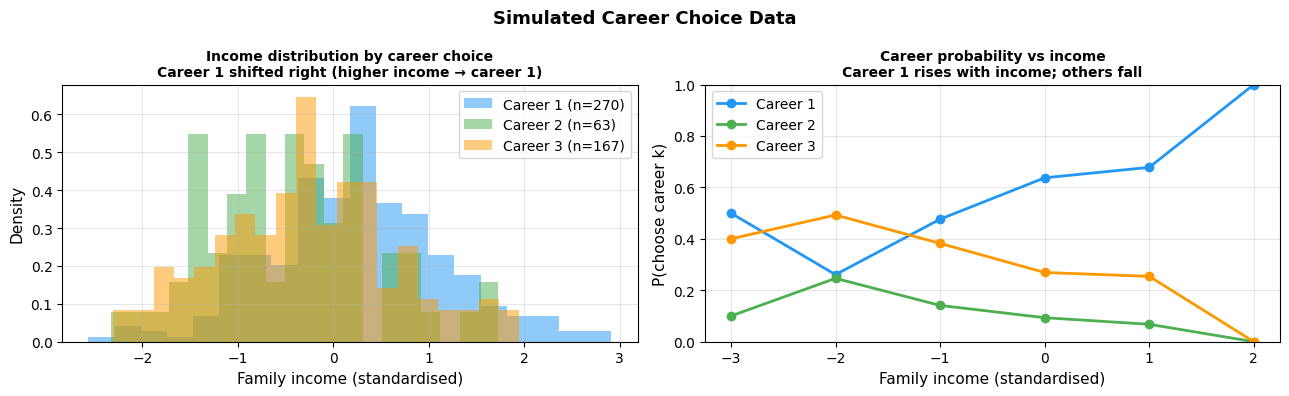

In [3]:
N = 500
family_income = rng.normal(0, 1, N)   # standardised

# True parameters (careers 1 and 2; career 3 is reference)
a_true = np.array([0.5, -1.0])    # intercepts
b_true = np.array([0.7,  0.0])    # income effects

# Scores for each individual × career
s = np.column_stack([
    a_true[0] + b_true[0] * family_income,   # career 1
    a_true[1] + b_true[1] * family_income,   # career 2
    np.zeros(N),                              # career 3 (reference)
])  # shape: (N, 3)

# Softmax → probabilities
exp_s = np.exp(s - s.max(axis=1, keepdims=True))
p_true = exp_s / exp_s.sum(axis=1, keepdims=True)   # (N, 3)

# Sample career for each individual
career = np.array([rng.choice(3, p=p_true[i]) for i in range(N)])

print(f'Career distribution: {np.bincount(career)} (careers 0, 1, 2)')
print(f'Proportions: {np.bincount(career)/N}')

# Visualise: how does income relate to career choice?
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
colors = ['#2196F3', '#4CAF50', '#FF9800']
for k, color in enumerate(colors):
    mask = career == k
    ax.hist(family_income[mask], bins=20, alpha=0.5, color=color,
            label=f'Career {k+1} (n={mask.sum()})', density=True)
ax.set_xlabel('Family income (standardised)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Income distribution by career choice\n'
             'Career 1 shifted right (higher income → career 1)', fontsize=10, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
income_bins = np.linspace(-3, 3, 7)
bin_idx = np.digitize(family_income, income_bins) - 1
for k, color in enumerate(colors):
    props = [np.mean(career[bin_idx == b] == k) if (bin_idx == b).sum() > 5 else np.nan
             for b in range(len(income_bins))]
    ax.plot(income_bins, props, 'o-', color=color, label=f'Career {k+1}', lw=2)
ax.set_xlabel('Family income (standardised)', fontsize=11)
ax.set_ylabel('P(choose career k)', fontsize=11)
ax.set_title('Career probability vs income\n'
             'Career 1 rises with income; others fall', fontsize=10, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.suptitle('Simulated Career Choice Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fit the Multinomial Logistic Model

In PyMC:
- `pm.Categorical` — the likelihood for one row per individual
- Scores built as a matrix: rows = individuals, columns = careers
- Reference category score fixed to 0 via `pt.zeros`
- PyMC applies softmax internally inside `pm.Categorical`

In [4]:
career_labels = ['career_1', 'career_2']

with pm.Model() as m_career:
    # Priors for K-1 = 2 intercepts and slopes (career 3 is reference)
    a = pm.Normal('a', mu=0, sigma=1,   shape=2)   # intercepts
    b = pm.Normal('b', mu=0, sigma=0.5, shape=2)   # income slopes

    # Score matrix: (N, 3)
    # Columns: [score_career1, score_career2, 0 (reference)]
    s1 = a[0] + b[0] * family_income
    s2 = a[1] + b[1] * family_income
    s3 = pt.zeros(N)                    # reference — fixed to 0

    scores = pm.math.stack([s1, s2, s3], axis=1)   # (N, 3)
    p = pm.Deterministic('p', pm.math.softmax(scores, axis=1))

    # Categorical likelihood — one draw per individual
    obs = pm.Categorical('obs', p=p, observed=career)

    idata_career = pm.sample(1000, tune=1000, chains=4,
                             target_accept=0.9, random_seed=42, progressbar=True)

print(az.summary(idata_career, var_names=['a', 'b'], hdi_prob=0.89).to_string())

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.712       7            731.05 draws/s   0:00:02   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.679       3            741.37 draws/s   0:00:02   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.535       3            747.52 draws/s   0:00:02   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.628       7            703.59 draws/s   0:00:02   0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


       mean     sd  hdi_5.5%  hdi_94.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
a[0]  0.494  0.102     0.331      0.654      0.002    0.002    3539.0    2975.0    1.0
a[1] -1.024  0.158    -1.277     -0.781      0.003    0.002    3422.0    2923.0    1.0
b[0]  0.589  0.111     0.423      0.776      0.002    0.002    3202.0    2849.0    1.0
b[1] -0.185  0.160    -0.435      0.077      0.003    0.002    3417.0    2492.0    1.0


In [5]:
# Compare estimated vs true parameters
post = idata_career.posterior
a_s  = post['a'].values.reshape(-1, 2)   # (S, 2)
b_s  = post['b'].values.reshape(-1, 2)   # (S, 2)

print('Parameter recovery:')
print(f'{"":15s} {"true":>8} {"estimated":>10} {"89% CI":>20}')
print('-' * 60)
for i, (name, true_val, samples) in enumerate([
    ('a[career_1]', a_true[0], a_s[:, 0]),
    ('a[career_2]', a_true[1], a_s[:, 1]),
    ('b[career_1]', b_true[0], b_s[:, 0]),
    ('b[career_2]', b_true[1], b_s[:, 1]),
]):
    lo, mid, hi = np.percentile(samples, [5.5, 50, 94.5])
    print(f'{name:15s} {true_val:>8.2f} {mid:>10.3f} [{lo:+.3f}, {hi:+.3f}]')

Parameter recovery:
                    true  estimated               89% CI
------------------------------------------------------------
a[career_1]         0.50      0.494 [+0.333, +0.656]
a[career_2]        -1.00     -1.022 [-1.276, -0.780]
b[career_1]         0.70      0.588 [+0.411, +0.767]
b[career_2]         0.00     -0.183 [-0.449, +0.068]


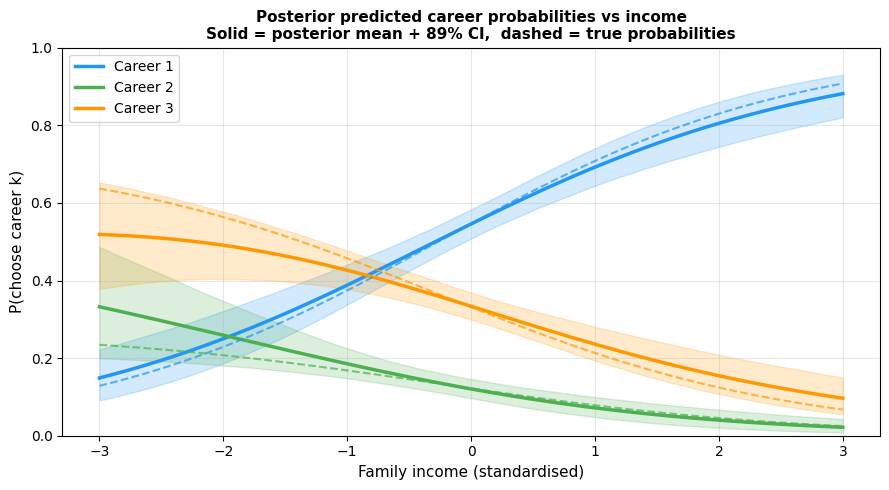

In [6]:
# Posterior predicted probabilities across income range
income_seq = np.linspace(-3, 3, 50)

# For each posterior sample, compute p(career k | income)
def pred_probs(income_val, a_s, b_s):
    s1 = a_s[:, 0] + b_s[:, 0] * income_val   # (S,)
    s2 = a_s[:, 1] + b_s[:, 1] * income_val   # (S,)
    s3 = np.zeros(len(a_s))
    scores = np.column_stack([s1, s2, s3])      # (S, 3)
    exp_s  = np.exp(scores - scores.max(axis=1, keepdims=True))
    return exp_s / exp_s.sum(axis=1, keepdims=True)  # (S, 3)

p_pred = np.stack([pred_probs(inc, a_s, b_s) for inc in income_seq])  # (50, S, 3)
p_mean = p_pred.mean(axis=1)   # (50, 3)
p_lo   = np.percentile(p_pred, 5.5,  axis=1)
p_hi   = np.percentile(p_pred, 94.5, axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800']
for k, color in enumerate(colors):
    ax.plot(income_seq, p_mean[:, k], color=color, lw=2.5, label=f'Career {k+1}')
    ax.fill_between(income_seq, p_lo[:, k], p_hi[:, k], color=color, alpha=0.2)

# Overlay true probabilities
s_true = np.column_stack([
    a_true[0] + b_true[0] * income_seq,
    a_true[1] + b_true[1] * income_seq,
    np.zeros(len(income_seq))
])
exp_true = np.exp(s_true - s_true.max(axis=1, keepdims=True))
p_true_seq = exp_true / exp_true.sum(axis=1, keepdims=True)
for k, color in enumerate(colors):
    ax.plot(income_seq, p_true_seq[:, k], '--', color=color, lw=1.5, alpha=0.7)

ax.set_xlabel('Family income (standardised)', fontsize=11)
ax.set_ylabel('P(choose career k)', fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Posterior predicted career probabilities vs income\n'
             'Solid = posterior mean + 89% CI,  dashed = true probabilities',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpreting the Coefficients

Coefficients are on the **log-odds scale relative to the reference category** (career 3).

- `a[career_1] > 0` → career 1 is more likely than career 3 at average income
- `b[career_1] > 0` → higher income increases the log-odds of career 1 vs career 3
- `b[career_2] ≈ 0` → income has no effect on career 2 vs career 3

**Important**: you cannot directly compare career 1 vs career 2 from the coefficients. To compare any two non-reference categories, compute the predicted probabilities and take the difference.

**Marginal effects are not constant** — because of softmax, the effect of income on P(career 1) depends on where all three probabilities are. This is the same non-linearity as logit for binomial.

In [7]:
# Effect of 1 SD increase in income on career probabilities
# Computed at low (-1), average (0), and high (+1) income
print('Effect of +1 SD income on P(career k):')
print(f'{"Income level":15s} {"ΔP(career 1)":>14} {"ΔP(career 2)":>14} {"ΔP(career 3)":>14}')
print('-' * 60)
for inc_base, label in [(-1, 'low  (−1 SD)'), (0, 'avg  (0)'), (1, 'high (+1 SD)')]:
    p_base = pred_probs(inc_base,     a_s, b_s).mean(axis=0)
    p_high = pred_probs(inc_base + 1, a_s, b_s).mean(axis=0)
    delta  = p_high - p_base
    print(f'{label:15s} {delta[0]:+14.3f} {delta[1]:+14.3f} {delta[2]:+14.3f}')

print()
print('The effect of income on probability is NOT constant — it depends on the current level.')
print('(Same non-linearity as logit link in binomial models)')

Effect of +1 SD income on P(career k):
Income level      ΔP(career 1)   ΔP(career 2)   ΔP(career 3)
------------------------------------------------------------
low  (−1 SD)            +0.158         -0.065         -0.093
avg  (0)                +0.146         -0.049         -0.098
high (+1 SD)            +0.113         -0.032         -0.081

The effect of income on probability is NOT constant — it depends on the current level.
(Same non-linearity as logit link in binomial models)


## Categorical vs Multinomial: Two Ways to Express the Same Model

Just like Bernoulli vs Binomial:

| Format | Distribution | When to use |
|--------|-------------|-------------|
| One row per individual | `Categorical(p)` | Individual-level data |
| Counts per category | `Multinomial(N, p)` | Aggregated data |

Same likelihood, same posterior. Our career model uses `Categorical` because we have one row per person.

## Why "Maximum Entropy Classifier"?

The multinomial logistic model is often called the **maximum entropy classifier** because:

1. Among all classifiers that produce the same expected feature values, it makes the **fewest additional assumptions** — it has maximum entropy.
2. The softmax link is the maximum entropy distribution for nominal outcomes with fixed expected scores.
3. This connects to Chapter 10's maximum entropy principle: given what we know (the linear predictors), assume as little as possible about the rest.

In practice: if your outcome is unordered categorical and you want a principled default — multinomial logistic is it.

## Key Insights

### 1. Softmax generalises logit to K categories
logit is softmax with K=2. For K>2, scores for K−1 categories are estimated; one is fixed to 0 (reference).

### 2. Coefficients are relative to the reference
Choice of reference category changes the numbers but not the predictions. Pick a meaningful reference (the most common category, or the "baseline" condition).

### 3. Marginal effects vary by location
A unit increase in income doesn't have a fixed effect on any probability — it depends on where you are on the probability simplex.

### 4. For ordered categories — use a different model
If categories have a natural order (e.g. low/medium/high), multinomial logistic throws that information away. Use **ordered logit** instead (Chapter 12).

---
*Chapter 11 — Statistical Rethinking (McElreath, 2nd ed.)*